# Best Experiments — DQN on ALE/Tennis-v5

It runs **10 experiments** for **Best** using the shared reusable `train.py`.


In [14]:
import os
import json
import sys
import subprocess
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR

while not (PROJECT_ROOT / "scripts" / "train.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

MEMBER = "best"
ENV_ID = "ALE/Tennis-v5"
SEED = 42
TOTAL_TIMESTEPS = 50_000
EVAL_EPISODES = 3

TRAIN_SCRIPT = PROJECT_ROOT / "scripts" / "train.py"
BASE_DIR = PROJECT_ROOT / "results" / MEMBER
MODEL_DIR = BASE_DIR / "models"
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook dir :", NOTEBOOK_DIR)
print("Project root :", PROJECT_ROOT)
print("Train script :", TRAIN_SCRIPT)
print("Base dir     :", BASE_DIR)
print("Train exists :", TRAIN_SCRIPT.exists())

Notebook dir : /Users/mwizera/Documents/Tenis_dqn_agent/experiments
Project root : /Users/mwizera/Documents/Tenis_dqn_agent
Train script : /Users/mwizera/Documents/Tenis_dqn_agent/scripts/train.py
Base dir     : /Users/mwizera/Documents/Tenis_dqn_agent/results/best
Train exists : True


In [7]:
#  Define 10 experiment configurations
experiments = [
    {'name': 'best_exp01_baseline', 'hp': dict(learning_rate=1e-4, gamma=0.99, batch_size=32, buffer_size=50_000, learning_starts=10_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.05)},
    {'name': 'best_exp02_low_lr', 'hp': dict(learning_rate=5e-5, gamma=0.99, batch_size=32, buffer_size=50_000, learning_starts=10_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.05)},
    {'name': 'best_exp03_high_lr', 'hp': dict(learning_rate=2e-4, gamma=0.99, batch_size=32, buffer_size=50_000, learning_starts=10_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.05)},
    {'name': 'best_exp04_high_gamma', 'hp': dict(learning_rate=1e-4, gamma=0.995, batch_size=32, buffer_size=50_000, learning_starts=10_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.03)},
    {'name': 'best_exp05_very_high_gamma', 'hp': dict(learning_rate=1e-4, gamma=0.999, batch_size=40, buffer_size=60_000, learning_starts=10_000, train_freq=6, gradient_steps=2, target_update_interval=15_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.015)},
    {'name': 'best_exp06_low_gamma_fast_updates', 'hp': dict(learning_rate=2e-4, gamma=0.97, batch_size=32, buffer_size=50_000, learning_starts=10_000, train_freq=2, gradient_steps=1, target_update_interval=4_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.03)},
    {'name': 'best_exp07_large_batch', 'hp': dict(learning_rate=1e-4, gamma=0.99, batch_size=64, buffer_size=50_000, learning_starts=10_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.12, exploration_initial_eps=1.0, exploration_final_eps=0.05)},
    {'name': 'best_exp08_more_exploration', 'hp': dict(learning_rate=1e-4, gamma=0.99, batch_size=32, buffer_size=50_000, learning_starts=10_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.20, exploration_initial_eps=1.0, exploration_final_eps=0.08)},
    {'name': 'best_exp09_less_exploration', 'hp': dict(learning_rate=1e-4, gamma=0.99, batch_size=32, buffer_size=50_000, learning_starts=10_000, train_freq=4, gradient_steps=1, target_update_interval=8_000, exploration_fraction=0.05, exploration_initial_eps=1.0, exploration_final_eps=0.02)},
    {'name': 'best_exp10_balanced_tuned', 'hp': dict(learning_rate=7.5e-5, gamma=0.995, batch_size=32, buffer_size=60_000, learning_starts=10_000, train_freq=4, gradient_steps=2, target_update_interval=8_000, exploration_fraction=0.12, exploration_initial_eps=1.0, exploration_final_eps=0.02)},
]

print(f'Prepared {len(experiments)} experiment configurations.')


Prepared 10 experiment configurations.


In [8]:
#  Helper to run one experiment through scripts/train.py
import sys
import subprocess
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR

# move up until we find scripts/train.py
while not (PROJECT_ROOT / "scripts" / "train.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_SCRIPT = PROJECT_ROOT / "scripts" / "train.py"

print("Notebook dir :", NOTEBOOK_DIR)
print("Project root :", PROJECT_ROOT)
print("Train script :", TRAIN_SCRIPT)
print("Exists?      :", TRAIN_SCRIPT.exists())

def run_experiment(exp: dict):
    hp = exp["hp"]

    cmd = [
        sys.executable, str(TRAIN_SCRIPT),
        "--member", MEMBER,
        "--experiment", exp["name"],
        "--env-id", ENV_ID,
        "--policy", "CnnPolicy",
        "--total-timesteps", str(TOTAL_TIMESTEPS),
        "--seed", str(SEED),
        "--learning-rate", str(hp["learning_rate"]),
        "--gamma", str(hp["gamma"]),
        "--batch-size", str(hp["batch_size"]),
        "--buffer-size", str(hp["buffer_size"]),
        "--learning-starts", str(hp["learning_starts"]),
        "--train-freq", str(hp["train_freq"]),
        "--gradient-steps", str(hp["gradient_steps"]),
        "--target-update-interval", str(hp["target_update_interval"]),
        "--exploration-initial-eps", str(hp["exploration_initial_eps"]),
        "--exploration-final-eps", str(hp["exploration_final_eps"]),
        "--exploration-fraction", str(hp["exploration_fraction"]),
        "--eval-freq", "10000",
        "--eval-episodes", str(EVAL_EPISODES),
    ]

    print("\nRunning:")
    print(" ".join(cmd))

    result = subprocess.run(
        cmd,
        cwd=str(PROJECT_ROOT),
        capture_output=True,
        text=True
    )

    print("\nSTDOUT:\n", result.stdout)
    if result.stderr:
        print("\nSTDERR:\n", result.stderr)

    if result.returncode != 0:
        raise RuntimeError(f"Experiment failed with exit code {result.returncode}")

Notebook dir : /Users/mwizera/Documents/Tenis_dqn_agent/experiments
Project root : /Users/mwizera/Documents/Tenis_dqn_agent
Train script : /Users/mwizera/Documents/Tenis_dqn_agent/scripts/train.py
Exists?      : True


In [9]:
#  Run all 10 experiments
for exp in experiments:
    run_experiment(exp)

print('All experiments finished.')



Running:
/Users/mwizera/Documents/Tenis_dqn_agent/.venv/bin/python /Users/mwizera/Documents/Tenis_dqn_agent/scripts/train.py --member best --experiment best_exp01_baseline --env-id ALE/Tennis-v5 --policy CnnPolicy --total-timesteps 50000 --seed 42 --learning-rate 0.0001 --gamma 0.99 --batch-size 32 --buffer-size 50000 --learning-starts 10000 --train-freq 4 --gradient-steps 1 --target-update-interval 10000 --exploration-initial-eps 1.0 --exploration-final-eps 0.05 --exploration-fraction 0.1 --eval-freq 10000 --eval-episodes 3

STDOUT:
 Using cpu device
Wrapping the env in a VecTransposeImage.

[START TRAINING]
{
  "member": "best",
  "experiment": "best_exp01_baseline",
  "env_id": "ALE/Tennis-v5",
  "policy": "CnnPolicy",
  "total_timesteps": 50000,
  "seed": 42,
  "device": "auto",
  "learning_rate": 0.0001,
  "gamma": 0.99,
  "batch_size": 32,
  "buffer_size": 50000,
  "learning_starts": 10000,
  "train_freq": 4,
  "gradient_steps": 1,
  "target_update_interval": 10000,
  "explorati

In [15]:
#  Read evaluation summaries into one table
rows = []
missing = []

for exp in experiments:
    eval_path = BASE_DIR / exp['name'] / f"{exp['name']}_eval.json"
    if eval_path.is_file():
        with open(eval_path, 'r', encoding='utf-8') as f:
            rows.append(json.load(f))
    else:
        missing.append(str(eval_path))

if missing:
    print('Missing evaluation files:')
    for m in missing:
        print(' -', m)

results_df = pd.DataFrame(rows).sort_values('mean_reward', ascending=False).reset_index(drop=True)
results_df


,member,experiment,policy,env_id,mean_reward,std_reward,train_minutes,model_path,best_model_path,training_csv_path,...,buffer_size,learning_starts,train_freq,gradient_steps,target_update_interval,exploration_initial_eps,exploration_final_eps,exploration_fraction,seed,total_timesteps
0,best,best_exp01_baseline,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,11.332719,results/best/models/best_exp01_baseline.zip,results/best/models/best_exp01_baseline_best/b...,results/best/logs/best_exp01_baseline_training...,...,50000,10000,4,1,10000,1.0,0.050,0.10,42,50000
1,best,best_exp02_low_lr,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,11.491807,results/best/models/best_exp02_low_lr.zip,results/best/models/best_exp02_low_lr_best/bes...,results/best/logs/best_exp02_low_lr_training_m...,...,50000,10000,4,1,10000,1.0,0.050,0.10,42,50000
2,best,best_exp03_high_lr,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,14.026485,results/best/models/best_exp03_high_lr.zip,results/best/models/best_exp03_high_lr_best/be...,results/best/logs/best_exp03_high_lr_training_...,...,50000,10000,4,1,10000,1.0,0.050,0.10,42,50000
3,best,best_exp04_high_gamma,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,13.098718,results/best/models/best_exp04_high_gamma.zip,results/best/models/best_exp04_high_gamma_best...,results/best/logs/best_exp04_high_gamma_traini...,...,50000,10000,4,1,10000,1.0,0.030,0.10,42,50000
4,best,best_exp05_very_high_gamma,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,17.717349,results/best/models/best_exp05_very_high_gamma...,results/best/models/best_exp05_very_high_gamma...,results/best/logs/best_exp05_very_high_gamma_t...,...,60000,10000,6,2,15000,1.0,0.015,0.10,42,50000
5,best,best_exp06_low_gamma_fast_updates,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,19.192401,results/best/models/best_exp06_low_gamma_fast_...,results/best/models/best_exp06_low_gamma_fast_...,results/best/logs/best_exp06_low_gamma_fast_up...,...,50000,10000,2,1,4000,1.0,0.030,0.10,42,50000
6,best,best_exp07_large_batch,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,14.058322,results/best/models/best_exp07_large_batch.zip,results/best/models/best_exp07_large_batch_bes...,results/best/logs/best_exp07_large_batch_train...,...,50000,10000,4,1,10000,1.0,0.050,0.12,42,50000
7,best,best_exp08_more_exploration,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,8.695134,results/best/models/best_exp08_more_exploratio...,results/best/models/best_exp08_more_exploratio...,results/best/logs/best_exp08_more_exploration_...,...,50000,10000,4,1,10000,1.0,0.080,0.20,42,50000
8,best,best_exp09_less_exploration,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,9.867036,results/best/models/best_exp09_less_exploratio...,results/best/models/best_exp09_less_exploratio...,results/best/logs/best_exp09_less_exploration_...,...,50000,10000,4,1,8000,1.0,0.020,0.05,42,50000
9,best,best_exp10_balanced_tuned,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,14.771193,results/best/models/best_exp10_balanced_tuned.zip,results/best/models/best_exp10_balanced_tuned_...,results/best/logs/best_exp10_balanced_tuned_tr...,...,60000,10000,4,2,8000,1.0,0.020,0.12,42,50000


In [16]:
#  Save results table
results_csv = TABLE_DIR / f'{MEMBER}_tennis_results.csv'
results_df.to_csv(results_csv, index=False)
print(f'Saved results table to: {results_csv}')
results_df


Saved results table to: /Users/mwizera/Documents/Tenis_dqn_agent/results/best/tables/best_tennis_results.csv


,member,experiment,policy,env_id,mean_reward,std_reward,train_minutes,model_path,best_model_path,training_csv_path,...,buffer_size,learning_starts,train_freq,gradient_steps,target_update_interval,exploration_initial_eps,exploration_final_eps,exploration_fraction,seed,total_timesteps
0,best,best_exp01_baseline,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,11.332719,results/best/models/best_exp01_baseline.zip,results/best/models/best_exp01_baseline_best/b...,results/best/logs/best_exp01_baseline_training...,...,50000,10000,4,1,10000,1.0,0.050,0.10,42,50000
1,best,best_exp02_low_lr,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,11.491807,results/best/models/best_exp02_low_lr.zip,results/best/models/best_exp02_low_lr_best/bes...,results/best/logs/best_exp02_low_lr_training_m...,...,50000,10000,4,1,10000,1.0,0.050,0.10,42,50000
2,best,best_exp03_high_lr,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,14.026485,results/best/models/best_exp03_high_lr.zip,results/best/models/best_exp03_high_lr_best/be...,results/best/logs/best_exp03_high_lr_training_...,...,50000,10000,4,1,10000,1.0,0.050,0.10,42,50000
3,best,best_exp04_high_gamma,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,13.098718,results/best/models/best_exp04_high_gamma.zip,results/best/models/best_exp04_high_gamma_best...,results/best/logs/best_exp04_high_gamma_traini...,...,50000,10000,4,1,10000,1.0,0.030,0.10,42,50000
4,best,best_exp05_very_high_gamma,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,17.717349,results/best/models/best_exp05_very_high_gamma...,results/best/models/best_exp05_very_high_gamma...,results/best/logs/best_exp05_very_high_gamma_t...,...,60000,10000,6,2,15000,1.0,0.015,0.10,42,50000
5,best,best_exp06_low_gamma_fast_updates,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,19.192401,results/best/models/best_exp06_low_gamma_fast_...,results/best/models/best_exp06_low_gamma_fast_...,results/best/logs/best_exp06_low_gamma_fast_up...,...,50000,10000,2,1,4000,1.0,0.030,0.10,42,50000
6,best,best_exp07_large_batch,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,14.058322,results/best/models/best_exp07_large_batch.zip,results/best/models/best_exp07_large_batch_bes...,results/best/logs/best_exp07_large_batch_train...,...,50000,10000,4,1,10000,1.0,0.050,0.12,42,50000
7,best,best_exp08_more_exploration,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,8.695134,results/best/models/best_exp08_more_exploratio...,results/best/models/best_exp08_more_exploratio...,results/best/logs/best_exp08_more_exploration_...,...,50000,10000,4,1,10000,1.0,0.080,0.20,42,50000
8,best,best_exp09_less_exploration,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,9.867036,results/best/models/best_exp09_less_exploratio...,results/best/models/best_exp09_less_exploratio...,results/best/logs/best_exp09_less_exploration_...,...,50000,10000,4,1,8000,1.0,0.020,0.05,42,50000
9,best,best_exp10_balanced_tuned,CnnPolicy,ALE/Tennis-v5,-1.0,0.0,14.771193,results/best/models/best_exp10_balanced_tuned.zip,results/best/models/best_exp10_balanced_tuned_...,results/best/logs/best_exp10_balanced_tuned_tr...,...,60000,10000,4,2,8000,1.0,0.020,0.12,42,50000


In [17]:
#  Identify Best's best model
if results_df.empty:
    raise ValueError('No results found. Run the experiments first.')

best_row = results_df.iloc[0]
best_experiment_name = best_row['experiment']
best_mean_reward = best_row['mean_reward']
best_model_path = best_row['best_model_path']

print('Best experiment:', best_experiment_name)
print('Best mean reward:', best_mean_reward)
print('Best model path:', best_model_path)


Best experiment: best_exp01_baseline
Best mean reward: -1.0
Best model path: results/best/models/best_exp01_baseline_best/best_model.zip


In [ ]:
#  Save best summary JSON
best_summary_path = TABLE_DIR / f'{MEMBER}_best_summary.json'
with open(best_summary_path, 'w', encoding='utf-8') as f:
    json.dump({'member': MEMBER, 'best_experiment': best_experiment_name, 'best_mean_reward': float(best_mean_reward), 'best_model_path': best_model_path}, f, indent=2)
print(f'Saved best summary to: {best_summary_path}')


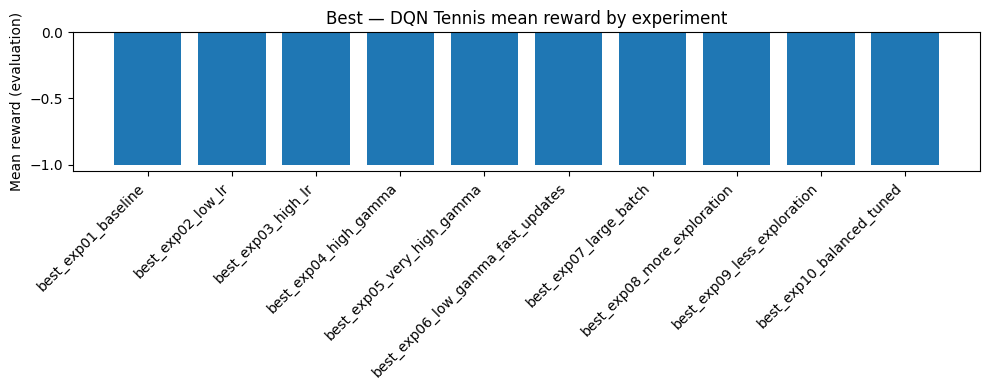

In [18]:
#  Visualization 1 — mean reward by experiment
_df = results_df.copy().sort_values('mean_reward', ascending=False)
plt.figure(figsize=(10, 4))
plt.bar(_df['experiment'], _df['mean_reward'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean reward (evaluation)')
plt.title('Best — DQN Tennis mean reward by experiment')
plt.tight_layout()
plt.show()


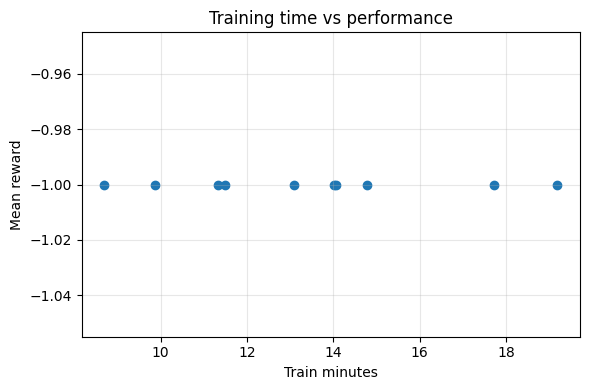

In [19]:
# Visualization 2 — training time vs performance
plt.figure(figsize=(6, 4))
plt.scatter(results_df['train_minutes'], results_df['mean_reward'])
plt.xlabel('Train minutes')
plt.ylabel('Mean reward')
plt.title('Training time vs performance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
# Play Best's best model
import os
import time
from pathlib import Path

import ale_py  # noqa: F401
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack

# Resolve best model path from project root
best_model_path_resolved = Path(best_model_path)
if not best_model_path_resolved.is_absolute():
    best_model_path_resolved = PROJECT_ROOT / best_model_path_resolved

print("Best model (raw)      :", best_model_path)
print("Best model (resolved) :", best_model_path_resolved)
print("Exists?               :", best_model_path_resolved.exists())

def make_play_env(seed: int, render_mode="human"):
    env = make_atari_env(
        ENV_ID,
        n_envs=1,
        seed=seed,
        env_kwargs={"render_mode": render_mode},
    )
    env = VecFrameStack(env, n_stack=4)
    return env

N_EPISODES = 1

if not best_model_path_resolved.exists():
    print("Best model not found:", best_model_path_resolved)
else:
    env = make_play_env(SEED)
    model = DQN.load(str(best_model_path_resolved), env=env)

    for ep in range(N_EPISODES):
        obs = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, rewards, dones, infos = env.step(action)
            ep_reward += float(rewards[0])
            done = bool(dones[0])
            time.sleep(1 / 60)

        print(f"Episode {ep + 1} return: {ep_reward:.2f}")

    env.close()

Best model (raw)      : results/best/models/best_exp01_baseline_best/best_model.zip
Best model (resolved) : /Users/mwizera/Documents/Tenis_dqn_agent/results/best/models/best_exp01_baseline_best/best_model.zip
Exists?               : True


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
objc[68550]: Class SDL_RumbleMotor is implemented in both /Users/mwizera/Documents/Tenis_dqn_agent/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x164b10d40) and /Users/mwizera/Documents/Tenis_dqn_agent/.venv/lib/python3.13/site-packages/ale_py/libSDL2-2.0.0.dylib (0x1666ec910). One of the two will be used. Which one is undefined.
objc[68550]: Class SDL_RumbleContext is implemented in both /Users/mwizera/Documents/Tenis_dqn_agent/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x164b10d90) and /Users/mwizera/Documents/Tenis_dqn_agent/.venv/lib/python3.13/site-packages/ale_py/libSDL2-2.0.0.dylib (0x1666ec960). One of the two will be used. Which one is undefined.
objc[68550]: Class SDLApplication is implemented in both /Users/mwizera/Documents/Tenis_dqn_agent/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x164b10890) and /Users/mwizera/Documents/

Wrapping the env in a VecTransposeImage.
Episode 1 return: -1.00
